#Table

In [ ]:
# if using a .ipynb in a folder, this heading is needed before importing
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

from src.poisson_hypergraph import GH
from matplotlib import pyplot as plt
import pandas as pd
import os 
import seaborn as sns
import xgi
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import statistics


sns.set_style("whitegrid")



simulated_annealing_ARI_averages = {}
for dataset in os.listdir("../throughput/simulated_annealing"):
    if dataset != "senate_bills_warmstart":
        ari_average_data = []
        for filename in os.listdir(f"../throughput/simulated_annealing/{dataset}/metrics"):
            
            if filename.endswith(".csv"):
                # df = pd.concat([df, pd.read_csv(f"throughput/community-structure-sims/{filename}")], ignore_index=True)
                ari_average_data.append(pd.read_csv(f"../throughput/simulated_annealing/{dataset}/metrics/{filename}").iloc[-1]["ari"])

        simulated_annealing_ARI_averages[dataset] = statistics.mean(ari_average_data)
            
print(simulated_annealing_ARI_averages)

modularity_ari = {}
for dataset in os.listdir("../throughput/modularity"):
    for filename in os.listdir(f"../throughput/modularity/{dataset}/metrics"):
        if filename.endswith(".csv"):
            # df = pd.concat([df, pd.read_csv(f"throughput/community-structure-sims/{filename}")], ignore_index=True)
            modularity_ari[dataset] = pd.read_csv(f"../throughput/modularity/{dataset}/metrics/{filename}").iloc[-1]["ari"]

print(modularity_ari)

spectral_ari = {}
for dataset in os.listdir("../throughput/spectral-clustering"):
    for filename in os.listdir(f"../throughput/spectral-clustering/{dataset}/metrics"):
        if filename.endswith(".csv"):
            # df = pd.concat([df, pd.read_csv(f"throughput/community-structure-sims/{filename}")], ignore_index=True)
            spectral_ari[dataset] = pd.read_csv(f"../throughput/spectral-clustering/{dataset}/metrics/{filename}").iloc[-1]["ari"]

print(spectral_ari)



df = pd.DataFrame(
    {
        "Simulated Annealing": [simulated_annealing_ARI_averages['senate_bills'], simulated_annealing_ARI_averages['primaryschool'], simulated_annealing_ARI_averages['highschool']],
        "Modularity": [modularity_ari['senate_bills'], modularity_ari['primaryschool'], modularity_ari['highschool']],
        "Spectral Clustering": [spectral_ari['senate_bills'], spectral_ari['primaryschool'], spectral_ari['highschool']]
    },
    index = ["Senate Bills", "Primary School", "High School"]
)

print(df.T.to_latex(
    float_format="%.3f",
    bold_rows=True,
    caption="Community detection results.",
    label="tab:results"
))

{'primaryschool': np.float64(0.15249982215417865), 'highschool': np.float64(0.0905545781252156), 'senate_bills': np.float64(0.1599100174347848)}
{'senate_bills': np.float64(-0.0026601790970648), 'primaryschool': np.float64(0.1583581228790267), 'highschool': np.float64(0.1820877864950317)}
{'senate_bills': np.float64(0.0048740191927033), 'primaryschool': np.float64(0.1752073417327733), 'highschool': np.float64(0.1820877864950317)}
\begin{table}
\caption{Community detection results.}
\label{tab:results}
\begin{tabular}{lrrr}
\toprule
 & Senate Bills & Primary School & High School \\
\midrule
\textbf{Simulated Annealing} & 0.160 & 0.152 & 0.091 \\
\textbf{Modularity} & -0.003 & 0.158 & 0.182 \\
\textbf{Spectral Clustering} & 0.005 & 0.175 & 0.182 \\
\bottomrule
\end{tabular}
\end{table}



#Boxplot!

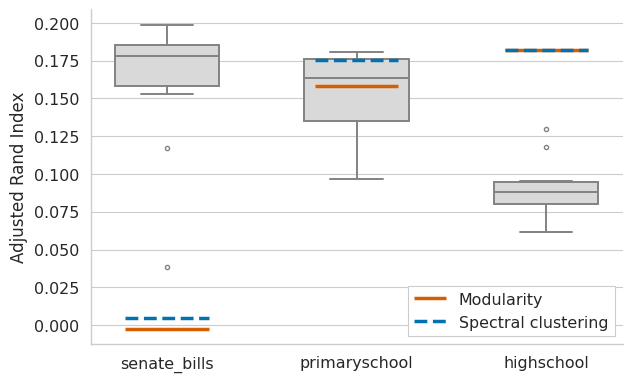

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Re-collect the individual ARI scores for the long-form DataFrame
sa_data = []

for dataset in ["senate_bills", "primaryschool", "highschool"]:
    folder_path = f"../throughput/simulated_annealing/{dataset}/metrics"
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            if filename.endswith(".csv"):
                ari_val = pd.read_csv(f"{folder_path}/{filename}").iloc[-1]["ari"]
                sa_data.append({"Dataset": dataset, "ARI": ari_val})

sa_df = pd.DataFrame(sa_data)

# 2. Define the order so the boxplot matches your hlines loop
order = ["senate_bills", "primaryschool", "highschool"]

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3,
)

fig, ax = plt.subplots(figsize=(6.5, 4.0))

# Boxplot
sns.boxplot(
    data=sa_df,
    x="Dataset",
    y="ARI",
    order=order,
    color="0.85",
    width=0.55,
    linewidth=1.4,
    fliersize=3,
    ax=ax,
)

# Overlay algorithm results
for i, dataset in enumerate(["senate_bills", "primaryschool", "highschool"]):
    ax.hlines(
        modularity_ari[dataset],
        i - 0.22,
        i + 0.22,
        color="#D55E00",       # Colorblind-friendly orange
        linewidth=2.5,
        linestyle="-",
        label="Modularity" if i == 0 else None,
        zorder=5,
    )

    ax.hlines(
        spectral_ari[dataset],
        i - 0.22,
        i + 0.22,
        color="#0072B2",       # Colorblind-friendly blue
        linewidth=2.5,
        linestyle="--",
        label="Spectral clustering" if i == 0 else None,
        zorder=5,
    )

# Labels
ax.set_xlabel("")
ax.set_ylabel("Adjusted Rand Index", fontsize=12)

# Remove unnecessary spines
sns.despine(ax=ax)

# Legend
ax.legend(
    loc="lower right",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    framealpha=1,
)

plt.tight_layout()
plt.savefig("community_detection_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.savefig("community_detection_boxplot.png", dpi=600, bbox_inches="tight")
plt.show()